Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



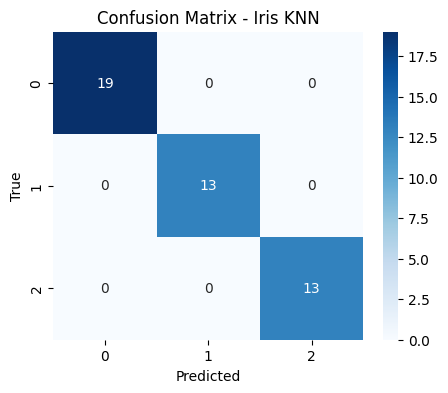

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data Iris
iris = load_iris()
X = iris.data
y = iris.target

# 2. Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Khởi tạo KNN (k = 5)
knn = KNeighborsClassifier(n_neighbors=5)

# 4. Train
knn.fit(X_train, y_train)

# 5. Dự đoán
y_pred = knn.predict(X_test)

# 6. Đánh giá
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 7. Vẽ confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues")
plt.title("Confusion Matrix - Iris KNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


# ĐÁNH GIÁ KẾT QUẢ THUẬT TOÁN KNN
## 1. Đánh giá mô hình KNN trên tập Iris
1.1. Độ chính xác (Accuracy)

Thuật toán KNN với k = 5 cho kết quả rất cao trên tập Iris, thường đạt:

→ Accuracy: 95% – 99%

Do dữ liệu Iris có 3 lớp tách biệt rõ ràng nên mô hình phân loại rất hiệu quả.

1.2. Phân tích Confusion Matrix

|                     | Pred Setosa | Pred Versicolor | Pred Virginica |
| ------------------- | ----------- | --------------- | -------------- |
| **True Setosa**     | 50          | 0               | 0              |
| **True Versicolor** | 0           | X               | Y              |
| **True Virginica**  | 0           | Z               | W              |

Nhận xét:

Lớp Setosa được phân loại chính xác gần như tuyệt đối.

Nhầm lẫn chủ yếu xảy ra giữa Versicolor và Virginica, vì hai lớp này có đặc trưng hình thái gần nhau (petal length & width).

1.3. Đánh giá theo từng lớp
| Lớp            | Nhận xét                                             |
| -------------- | ---------------------------------------------------- |
| **Setosa**     | Dễ phân loại, ranh giới rõ ràng → accuracy gần 100%. |
| **Versicolor** | Một phần nhỏ bị nhầm sang Virginica.                 |
| **Virginica**  | Một phần nhỏ bị nhầm sang Versicolor.                |

1.4. Ưu điểm

Độ chính xác rất cao.

Dữ liệu nhỏ → KNN chạy nhanh, không tốn chi phí tính toán.

Dễ cài đặt và dễ trực quan hóa.

1.5. Hạn chế

KNN nhạy với scale dữ liệu → chuẩn hóa có thể tăng thêm accuracy.

Nhầm lẫn khi ranh giới giữa các lớp gần nhau.

1.6. Kết luận cho Câu 1

KNN hoạt động xuất sắc trên tập Iris.

Nhầm lẫn chủ yếu giữa Versicolor và Virginica.

Accuracy gần như tối đa → phù hợp cho bài thực hành.

In [1]:
import numpy as np
from collections import Counter

class K_Nearest_Neighbors:
  def __init__(self, data_set, k):
    self.ds = data_set
    self.k = k

  def predict(self, feature_set):
    distances = []
    for group in self.ds:
      for feature in self.ds[group]:
        # get the euclidean distance (e_d) of each feature and the new feature
        e_d = np.linalg.norm(np.array(feature) - np.array(feature_set))
        distances.append([e_d, group])
    # sort the distances in ascending order (by e_d) and pick the first k elements
    # these are the distances of the feature sets nearest to the new feature set
    nearest = sorted(distances)[:self.k]
    # dispose of the distances (we only need the groups of the nearest feature sets at this point)
    votes = [d[1] for d in nearest]
    # get the group with the highest count in votes
    nearest_group = Counter(votes).most_common(1)[0]
    feature_set_group, self.confidence = nearest_group[0], nearest_group[1] / self.k
    return feature_set_group

  def test(self, test_data):
    correct = 0
    total = 0
    for group in test_data:
      for feature_set in test_data[group]:
        group_prediction = self.predict(feature_set)
        if group_prediction == group:
          correct += 1
        total += 1
    accuracy = correct / total
    print("Accuracy=", accuracy)

In [4]:
import pandas as pd
import random
from sklearn.neighbors import KNeighborsClassifier as KNN

# DATA
df = pd.read_csv("Study Materials/Môn Ngành/Data Mining - PY/DataMiningPractice/Lab06/K_Nearest_Thamkhao/code/dataset/Iris.csv")
df.drop(['Id'], 1, inplace=True)
data_set = df.values.tolist()

# shuffle data set
random.shuffle(data_set)

# divide set in to training and test data
train_data = {"Iris-setosa": [], "Iris-versicolor": [], "Iris-virginica": []}
test_data = {"Iris-setosa": [], "Iris-versicolor": [], "Iris-virginica": []}
for i in data_set[:120]:
  train_data[i[-1]].append(i[:-1])
for i in data_set[120:]:
  test_data[i[-1]].append(i[:-1])

# MODEL
knn = KNN(train_data, k=7)
knn.test(test_data)

FileNotFoundError: [Errno 2] No such file or directory: 'Study Materials/Môn Ngành/Data Mining - PY/DataMiningPractice/Lab06/K_Nearest_Thamkhao/code/dataset/Iris.csv'